## 📊 Описание набора данных
Используемый датасет представляет собой выгрузку сырых данных из рекламного кабинета Google Ads. Данные включают показатели по кампаниям, устройствам, ключевым словам и финансовым результатам.

### Структура таблицы:

| Столбец | Описание | Тип данных |
| :--- | :--- | :--- |
| **Ad_ID** | Уникальный идентификатор объявления | `String` |
| **Campaign_Name** | Название рекламной кампании (содержало опечатки) | `String` |
| **Clicks** | Количество переходов по объявлению | `Float` |
| **Impressions** | Общее количество показов объявления | `Float` |
| **Cost** | Затраты на показ объявления (включали знаки валют) | `String` |
| **Leads** | Количество полученных заявок | `Float` |
| **Conversions** | Количество успешно завершенных целевых действий | `Float` |
| **Sale_Amount** | Выручка, полученная с продаж (очищена от знаков $) | `String` |
| **Ad_Date** | Дата показа объявления (смешанные форматы записи) | `String` |
| **Location** | Географическая локация (город Хайдарабад) | `String` |
| **Device** | Тип устройства (Mobile, Desktop, Tablet) | `String` |
| **Keyword** | Ключевое слово, по которому было показано объявление | `String` |



In [ ]:
%pip install seaborn


In [3]:
import os
import pandas as pd
import seaborn as sns
import kagglehub
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats


In [4]:
path = kagglehub.dataset_download("nayakganesh007/google-ads-sales-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Игорь\.cache\kagglehub\datasets\nayakganesh007\google-ads-sales-dataset\versions\1


### 1. Предобработка и очистка данных
На этом этапе «грязные» данные были приведены в пригодный для анализа вид:
* **Типизация:** Данные в колонках `cost` и `sale_amount` очищены от знаков валют (`$`) и приведены к формату `float`.
* **Стандартизация:** С помощью методов строк (`str.lower`, `replace`) исправлены опечатки в городах (`location`), устройствах (`device`) и ключевых словах (`keyword`).
* **Работа с датами:** Столбец `ad_date` переведен в `datetime`, успешно обработаны смешанные форматы записи (YYYY/MM/DD и DD-MM-YY).
* **Обработка пропусков:** Восстановлены расчетные метрики (например, `conversion_rate` пересчитан на основе кликов и конверсий), что позволило сохранить **100% данных** без потери строк.

In [5]:
files = os.listdir(path)
print("Файлы в папке:", files)

Файлы в папке: ['GoogleAds_DataAnalytics_Sales_Uncleaned.csv']


In [6]:
full_path = os.path.join(path, 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv')
df = pd.read_csv(full_path)

In [8]:
df.head()

,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


In [9]:
df.columns = df.columns.str.lower()
df.rename(columns={"conversion rate": "conversion_rate"}, inplace=True)

In [10]:
df.dtypes

ad_id                  str
campaign_name          str
clicks             float64
impressions        float64
cost                   str
leads              float64
conversions        float64
conversion_rate    float64
sale_amount            str
ad_date                str
location               str
device                 str
keyword                str
dtype: object

In [11]:
df.shape

(2600, 13)

In [12]:
df.ad_date.unique()

<StringArray>
['2024-11-16', '20-11-2024', '2024/11/16', '2024-11-26', '2024-11-22',
 '16-11-2024', '06-11-2024', '2024/11/24', '2024/11/12', '14-11-2024',
 '2024/11/22', '2024/11/27', '12-11-2024', '2024-11-04', '2024-11-29',
 '2024-11-10', '2024/11/07', '2024-11-05', '2024/11/21', '2024/11/08',
 '2024-11-20', '30-11-2024', '2024-11-02', '2024-11-21', '2024-11-23',
 '2024/11/13', '2024-11-08', '22-11-2024', '2024/11/03', '2024-11-25',
 '01-11-2024', '2024-11-07', '09-11-2024', '2024-11-14', '2024/11/09',
 '29-11-2024', '15-11-2024', '11-11-2024', '2024-11-24', '21-11-2024',
 '2024/11/26', '26-11-2024', '18-11-2024', '2024-11-11', '23-11-2024',
 '2024/11/20', '27-11-2024', '04-11-2024', '2024/11/06', '2024-11-09',
 '2024/11/25', '17-11-2024', '2024/11/28', '2024-11-03', '2024-11-19',
 '2024/11/23', '03-11-2024', '2024/11/15', '2024-11-01', '2024-11-28',
 '2024-11-15', '2024/11/17', '2024-11-30', '24-11-2024', '05-11-2024',
 '2024-11-18', '2024/11/04', '2024/11/05', '2024/11/01', '2024/

In [13]:
df.cost = df.cost.str.replace('$', '')
df.sale_amount = df.sale_amount.str.replace('$', '')
df.ad_date = df.ad_date.str.replace('/', '-')

In [14]:
df.cost = df.cost.astype('float')
df.sale_amount = df.sale_amount.astype('float')

In [15]:
def parse_date_flexible(date_str):
    for i in ('%Y-%m-%d', '%d-%m-%Y', '%Y/%m/%d'):
        try:
            return pd.to_datetime(date_str, format=i)
        except (ValueError, TypeError):
            continue
    return pd.NaT

In [16]:
df['ad_date_original'] = df['ad_date'].copy()
df['ad_date'] = pd.to_datetime(df['ad_date'], dayfirst=True, errors='coerce')
mask = df['ad_date'].isna()
df.loc[mask, 'ad_date'] = df.loc[mask, 'ad_date_original'].apply(parse_date_flexible)
df = df.drop(columns=['ad_date_original'])

C:\Users\Игорь\AppData\Local\Temp\ipykernel_10920\259191566.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['ad_date'] = pd.to_datetime(df['ad_date'], dayfirst=True, errors='coerce')


In [17]:
df.campaign_name.unique()

<StringArray>
[  'DataAnalyticsCourse',   'Data Anlytics Corse', 'Data Analytcis Course',
  'Data Analytics Corse']
Length: 4, dtype: str

In [18]:
name_map = {
    'Data Anlytics Corse': 'Data Analytics Course',
    'Data Analytcis Course': 'Data Analytics Course',
    'Data Analytics Corse': 'Data Analytics Course',
    'DataAnalyticsCourse': 'Data Analytics Course'
}

df.campaign_name = df.campaign_name.replace(name_map)


In [19]:
df.location.unique()

<StringArray>
['hyderabad', 'HYDERABAD', 'Hyderbad', 'hydrebad']
Length: 4, dtype: str

In [20]:
location_map = {
    'HYDERABAD': 'hyderabad',
    'Hyderbad': 'hyderabad',
    'hydrebad': 'hyderabad'
}
df.location = df.location.replace(location_map)

In [21]:
df.device.unique()

<StringArray>
['desktop',  'mobile', 'Desktop',  'tablet',  'MOBILE',  'TABLET',  'Tablet',
  'Mobile', 'DESKTOP']
Length: 9, dtype: str

In [22]:
df.device = df.device.str.lower()

In [23]:
df.keyword.unique()

<StringArray>
[  'learn data analytics',  'data analytics course',  'data analitics online',
 'data anaytics training',   'online data analytic',     'analytics for data']
Length: 6, dtype: str

In [24]:
keyword_map = {
    'data analitics online': 'data analytics online',
    'data anaytics training': 'data analytics training',
    'online data analytic': 'online data analytics'
}

df.keyword = df.keyword.replace(keyword_map)


In [25]:
df.isna().sum()

ad_id                0
campaign_name        0
clicks             112
impressions         54
cost                97
leads               48
conversions         74
conversion_rate    626
sale_amount        139
ad_date              0
location             0
device               0
keyword              0
dtype: int64

In [26]:
cols_to_fix = ['clicks', 'cost', 'impressions', 'leads', 'conversions', 'sale_amount']
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())


In [27]:
df.isna().sum()

ad_id                0
campaign_name        0
clicks               0
impressions          0
cost                 0
leads                0
conversions          0
conversion_rate    626
sale_amount          0
ad_date              0
location             0
device               0
keyword              0
dtype: int64

In [28]:
df.conversion_rate = df.conversions / df.clicks

### 2. Исследовательский анализ
Для поиска закономерностей были построены:
* **Гистограммы**
* **Тепловая корреляции**
* **Боксплоты** 

### Анализ распределения основных метрик

На данном этапе рассмотрены распределения ключевых показателей рекламной кампании: количества показов, кликов, затрат и выручки.  
Это позволяет оценить общий разброс значений, выявить возможные выбросы и понять, насколько данные однородны.


In [30]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

Text(0, 0.5, 'Количество')

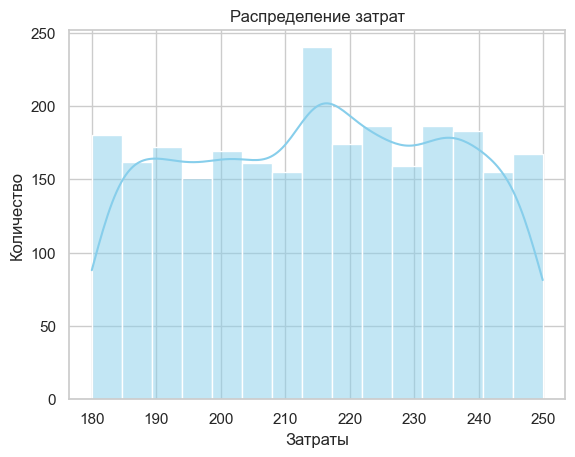

In [31]:
sns.histplot(df['cost'], kde=True, color='skyblue')
plt.title('Распределение затрат')
plt.xlabel('Затраты')
plt.ylabel('Количество')

Text(0, 0.5, 'Количество')

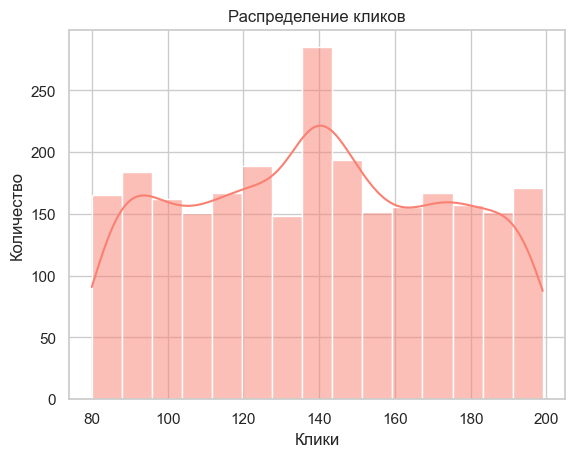

In [32]:
sns.histplot(df['clicks'], kde=True, color='salmon')
plt.title('Распределение кликов')
plt.xlabel('Клики')
plt.ylabel('Количество')

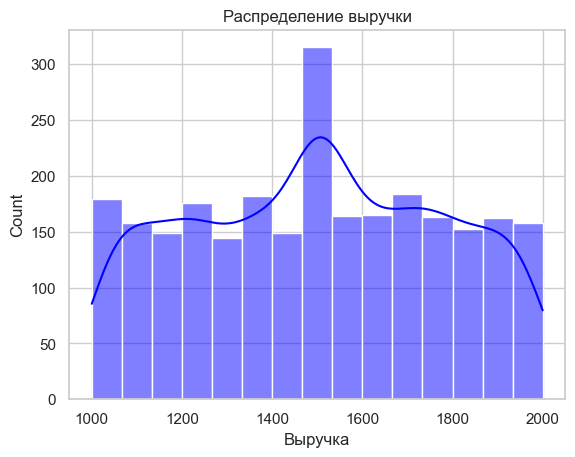

In [33]:
sns.histplot(df['sale_amount'], kde=True, color='blue')
plt.title('Распределение выручки')
plt.xlabel('Выручка')
plt.show()


Text(0.5, 0, 'Показы')

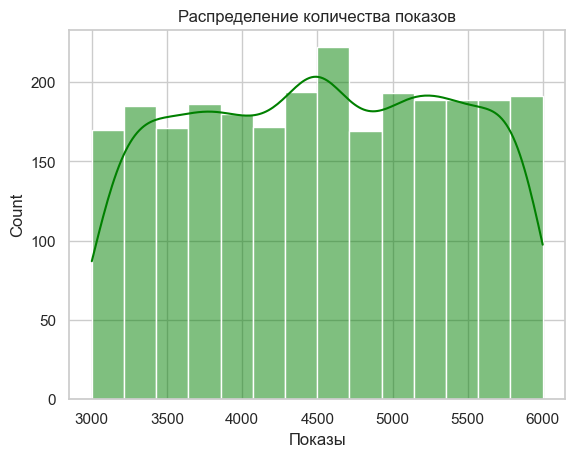

In [34]:
sns.histplot(df['impressions'], kde=True, color='green')
plt.title('Распределение количества показов')
plt.xlabel('Показы')



### Анализ распределения конверсии
На гистограмме представлено распределение коэффициента конверсии для всех рекламных объявлений.

*   Распределение с положительной асимметрией. Большинство объявлений имеют конверсию в диапазоне **3% – 6%**.
*   Данные не имеют резких разрывов, что подтверждает корректность проведенной очистки и восстановления пропущенных значений.


Text(0.5, 0, 'Коэффициент конверсии')

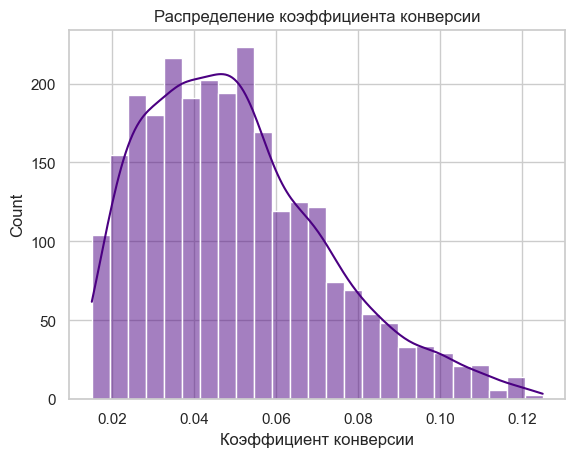

In [35]:
sns.histplot(df['conversion_rate'], kde=True, color='indigo')
plt.title('Распределение коэффициента конверсии')
plt.xlabel('Коэффициент конверсии')

### Анализ конверсии в разрезе устройств

Для сравнения эффективности типов устройств была построена диаграмма размаха.
*   **Сравнительная эффективность:** Медианные значения коэффициента конверсии для **Desktop**, **Mobile** и **Tablet** находятся на очень близком уровне. Это говорит о том, что сайт одинаково удобен для пользователей.
*   **Стабильность данных:** Ящики имеют почти одинаковую высоту. Это указывает на схожую вариативность данных во всех трех сегментах.

**Вывод:** Ни одно из устройств не является явным аутсайдером.

Text(0, 0.5, 'Коэффициент конверсии')

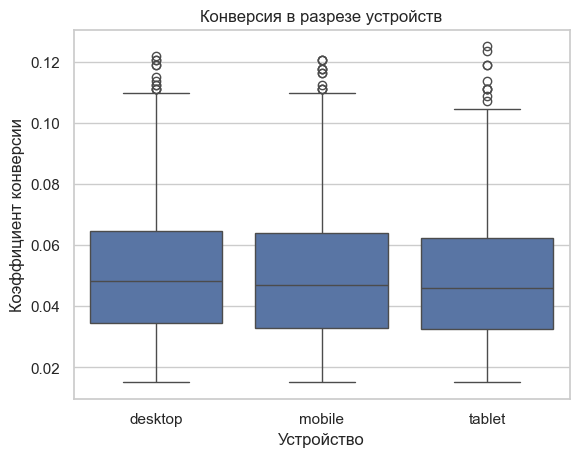

In [36]:
sns.boxplot(x = 'device', y = 'conversion_rate', data = df)
plt.title('Конверсия в разрезе устройств')
plt.xlabel('Устройство')
plt.ylabel('Коэффициент конверсии')

### Анализ временных рядов: Динамика показов и кликов

Для оценки стабильности рекламных кампаний в течение ноября 2024 года были построены линейные графики суммарных показов и кликов по датам.

Графики показов и кликов практически полностью дублируют друг друга. Все значимые пики (13, 18, 25 ноября) и глубокие просадки (5, 17 ноября) происходят одновременно. Это подтверждает техническую исправность системы трекинга: количество кликов пропорционално росту показов.



(array([20028., 20032., 20036., 20040., 20044., 20048., 20052., 20056.,
        20058.]),
 [Text(20028.0, 0, '2024-11-01'),
  Text(20032.0, 0, '2024-11-05'),
  Text(20036.0, 0, '2024-11-09'),
  Text(20040.0, 0, '2024-11-13'),
  Text(20044.0, 0, '2024-11-17'),
  Text(20048.0, 0, '2024-11-21'),
  Text(20052.0, 0, '2024-11-25'),
  Text(20056.0, 0, '2024-11-29'),
  Text(20058.0, 0, '2024-12-01')])

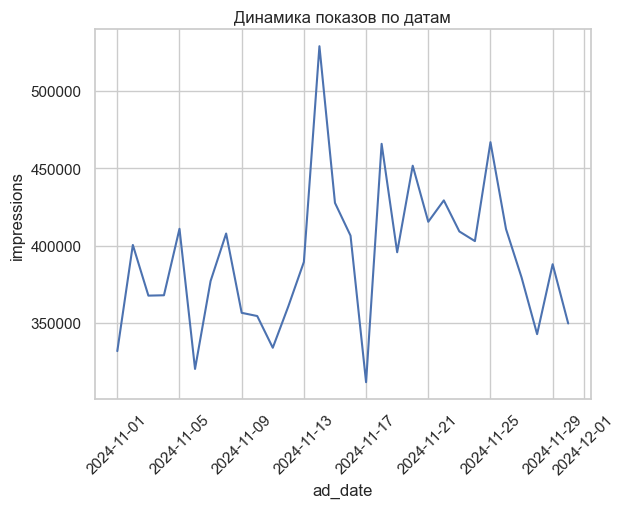

In [37]:
daily_impressions = df.groupby('ad_date', as_index = False).agg({'impressions': sum})
sns.lineplot(x='ad_date', y='impressions', data=daily_impressions)
plt.title('Динамика показов по датам')
plt.xticks(rotation=45)


(array([20028., 20032., 20036., 20040., 20044., 20048., 20052., 20056.,
        20058.]),
 [Text(20028.0, 0, '2024-11-01'),
  Text(20032.0, 0, '2024-11-05'),
  Text(20036.0, 0, '2024-11-09'),
  Text(20040.0, 0, '2024-11-13'),
  Text(20044.0, 0, '2024-11-17'),
  Text(20048.0, 0, '2024-11-21'),
  Text(20052.0, 0, '2024-11-25'),
  Text(20056.0, 0, '2024-11-29'),
  Text(20058.0, 0, '2024-12-01')])

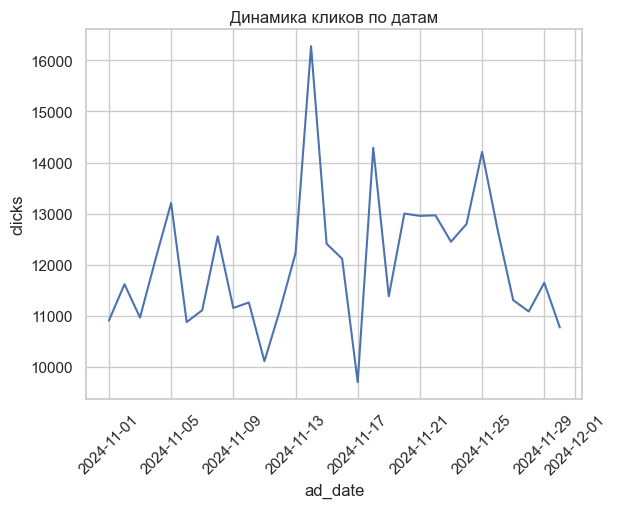

In [38]:
daily_clicks = df.groupby('ad_date', as_index = False).agg({'clicks': sum})
sns.lineplot(x='ad_date', y='clicks', data=daily_clicks)
plt.title('Динамика кликов по датам')
plt.xticks(rotation=45)

### Матрица корреляции метрик

Для выявления скрытых взаимосвязей между показателями была построена тепловая карта корреляции Пирсона.



Text(0.5, 1.0, 'Корреляция метрик')

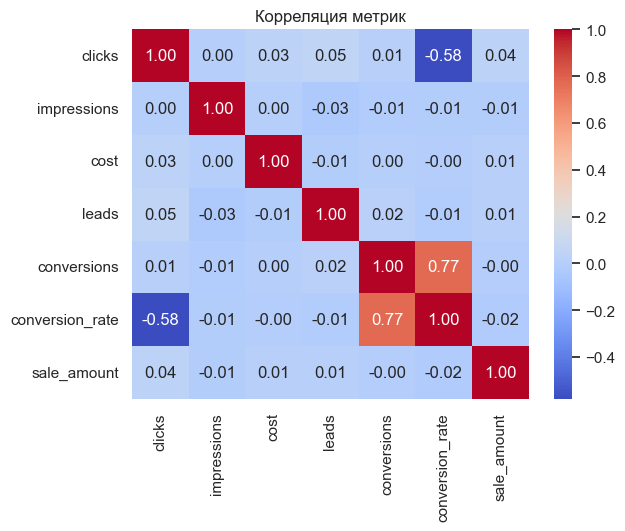

In [39]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция метрик')

### Структура кампании: распределение по устройствам и ключевым словам

Перед переходом к статистическим тестам важно убедиться, что данные равномерно распределены между группами. Несбалансированные группы могут исказить результаты дальнейшего сравнительного анализа.

### Распределение рекламной активности по типам устройств

Для оценки охвата в разрезе платформ был построен барчарт, отображающий количество уникальных рекламных записей для каждого типа устройств.

*   Визуально видно, что количество объявлений для **Desktop**, **Mobile** и **Tablet** практически идентично.  
*   Это указывает на то, что рекламная кампания была настроена с равномерным распределением веса между всеми типами устройств.

Для статистического подтверждения данного наблюдения был применён χ²-тест согласия. Нулевая гипотеза предполагала равномерное распределение объявлений между устройствами. Результаты теста показали отсутствие статистически значимых отклонений от равномерного распределения (p-value > 0.05), что подтверждает сделанный визуальный вывод.

**Вывод:** Кампания охватывает все сегменты пользователей в равной степени. Это создаёт корректную основу для дальнейшего сравнительного анализа эффективности, так как влияние различий в объёме данных между группами минимально.


C:\Users\Игорь\AppData\Local\Temp\ipykernel_10920\1100709001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'device', y = 'ad_id', palette= 'rocket', data = df_device)


Text(0.5, 1.0, 'Распределение рекламных показов по типам устройств')

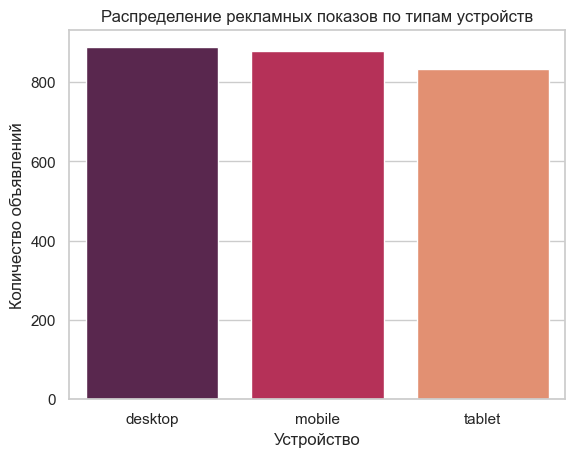

In [40]:
df_device = df.groupby('device', as_index = False).agg({'ad_id': 'count'})
sns.barplot(x = 'device', y = 'ad_id', palette= 'rocket', data = df_device)
plt.xlabel('Устройство')
plt.ylabel('Количество объявлений')
plt.title('Распределение рекламных показов по типам устройств')


In [41]:
observed = df_device['ad_id'].values

expected = [observed.sum() / len(observed)] * len(observed)

statistic, p_value = stats.chisquare(observed, expected)

if p_value < 0.05:
    print(f"распределение по устройствам неравномерно (p-value = {p_value:.4f})")
else:
    print(f"распределение по устройствам можно считать равномерным (p-value = {p_value:.4f})")

распределение по устройствам можно считать равномерным (p-value = 0.3858)


### Частота использования ключевых слов в запросах

Для анализа структуры поисковых запросов был построен барчарт, отражающий частоту использования различных ключевых слов.

*   Визуально частоты использования ключевых слов находятся в сопоставимых диапазонах, без ярко выраженных доминирующих значений.  
*   Это указывает на отсутствие явного перекоса рекламного трафика в сторону отдельных запросов.

Для статистической проверки был применён χ²-тест согласия. Нулевая гипотеза предполагала равномерное распределение частот между ключевыми словами.

Результаты теста показали, что различия не являются статистически значимыми (p-value = 0.7653). Таким образом, нет оснований отвергать нулевую гипотезу.

**Вывод:** Распределение ключевых слов можно считать равномерным. Это означает, что все группы представлены сопоставимым объёмом данных, что создаёт корректную основу для дальнейшего сравнения их эффективности.


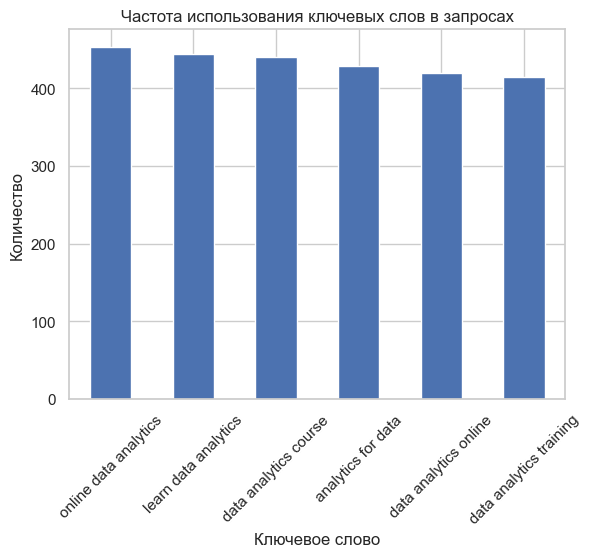

In [42]:
product_counts = df.keyword.value_counts()
product_counts.plot(kind='bar')
plt.xlabel('Ключевое слово')
plt.ylabel('Количество')
plt.title('Частота использования ключевых слов в запросах')
plt.xticks(rotation=45)
plt.show()

In [43]:
df_keyword = df.groupby('keyword', as_index = False).agg({'ad_id': 'count'})
observed = df_keyword['ad_id'].values

expected = [observed.sum() / len(observed)] * len(observed)

statistic, p_value = stats.chisquare(observed, expected)

if p_value < 0.05:
    print(f"распределение по ключевым словам неравномерно (p-value = {p_value:.4f})")
else:
    print(f"распределение по ключевым словам можно считать равномерным (p-value = {p_value:.4f})")

распределение по ключевым словам можно считать равномерным (p-value = 0.7653)


## Статистическая проверка гипотез

Переходим к вопросу: **влияют ли устройство и ключевое слово на эффективность кампании?**

Для каждой метрики применяется стандартная цепочка: проверка нормальности → равенство дисперсий (тест Левена) → сравнение групп (ANOVA или Краскел–Уоллис).

Производные метрики рассчитываются здесь, чтобы они были доступны для всех последующих тестов:

In [44]:
df['CTR'] = df.clicks / df.impressions
df['ROAS'] = df['sale_amount'] / df['cost']

### 5.1 Conversion Rate по устройствам
Для проверки различий в метрике `conversion_rate` между устройствами проведены статистические тесты.

In [45]:
for i in ['desktop', 'mobile', 'tablet']:
    statistic, p_value = stats.normaltest(df.query("device == @i")['conversion_rate'])
    if p_value <= 0.05:
        print(f"признак {i}: распределение не нормальное (p-value = {p_value:.4f})")
    else:
        print(f"признак {i}: распределение нормальное (p-value = {p_value:.4f})")


признак desktop: распределение не нормальное (p-value = 0.0000)
признак mobile: распределение не нормальное (p-value = 0.0000)
признак tablet: распределение не нормальное (p-value = 0.0000)


In [46]:
statistic, p_value = stats.levene(df.query("device == 'desktop'")['conversion_rate'], 
                                  df.query("device == 'mobile'")['conversion_rate'], 
                                  df.query("device == 'tablet'")['conversion_rate'])
if p_value <= 0.05:
        print(f"диспресии как минимум одной из групп значимо отличается (p-value = {p_value:.4f})")
else:
    print(f"дисперсии всех групп равны (p-value = {p_value:.4f})")

дисперсии всех групп равны (p-value = 0.3105)


In [47]:
statistic, p_value = stats.f_oneway(df.query("device == 'desktop'")['conversion_rate'], 
                                  df.query("device == 'mobile'")['conversion_rate'], 
                                  df.query("device == 'tablet'")['conversion_rate'])
if p_value <= 0.05:
        print(f"среднее хотя одной из групп значимо отличается от средних в других группах (p-value = {p_value:.4f})")
else:
    print(f"средние всех групп равны (p-value = {p_value:.4f})")

средние всех групп равны (p-value = 0.1654)


### 5.2 Conversion Rate по ключевым словам
Аналогичная проверка для ключевых слов.

In [48]:
for i in ['learn data analytics', 'data analytics course', 'data analytics online', 'data analytics training', 'online data analytics', 'analytics for data']:
    statistic, p_value = stats.normaltest(df.query("keyword == @i")['conversion_rate'])
    if p_value <= 0.05:
        print(f"признак {i}: распределение не нормальное (p-value = {p_value:.4f})")
    else:
        print(f"признак {i}: распределение нормальное (p-value = {p_value:.4f})")


признак learn data analytics: распределение не нормальное (p-value = 0.0000)
признак data analytics course: распределение не нормальное (p-value = 0.0000)
признак data analytics online: распределение не нормальное (p-value = 0.0000)
признак data analytics training: распределение не нормальное (p-value = 0.0000)
признак online data analytics: распределение не нормальное (p-value = 0.0000)
признак analytics for data: распределение не нормальное (p-value = 0.0000)


In [49]:
statistic, p_value = stats.levene(df.query("keyword == 'learn data analytics'")['conversion_rate'], 
                                  df.query("keyword == 'data analytics course'")['conversion_rate'], 
                                  df.query("keyword == 'data analytics online'")['conversion_rate'],
                                  df.query("keyword == 'data analytics training'")['conversion_rate'],
                                  df.query("keyword == 'online data analytics'")['conversion_rate'],
                                  df.query("keyword == 'analytics for data'")['conversion_rate'])
if p_value <= 0.05:
        print(f"диспресии как минимум одной из групп значимо отличается (p-value = {p_value:.4f})")
else:
    print(f"дисперсии всех групп равны (p-value = {p_value:.4f})")

дисперсии всех групп равны (p-value = 0.1683)


In [50]:
statistic, p_value = stats.f_oneway(df.query("keyword == 'learn data analytics'")['conversion_rate'], 
                                    df.query("keyword == 'data analytics course'")['conversion_rate'], 
                                    df.query("keyword == 'data analytics online'")['conversion_rate'],
                                    df.query("keyword == 'data analytics training'")['conversion_rate'],
                                    df.query("keyword == 'online data analytics'")['conversion_rate'],
                                    df.query("keyword == 'analytics for data'")['conversion_rate'])
if p_value <= 0.05:
        print(f"среднее хотя одной из групп значимо отличается от средних в других группах (p-value = {p_value:.4f})")
else:
    print(f"средние всех групп равны (p-value = {p_value:.4f})")

средние всех групп равны (p-value = 0.3772)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'learn data analytics'),
  Text(1, 0, 'data analytics course'),
  Text(2, 0, 'data analytics online'),
  Text(3, 0, 'data analytics training'),
  Text(4, 0, 'online data analytics'),
  Text(5, 0, 'analytics for data')])

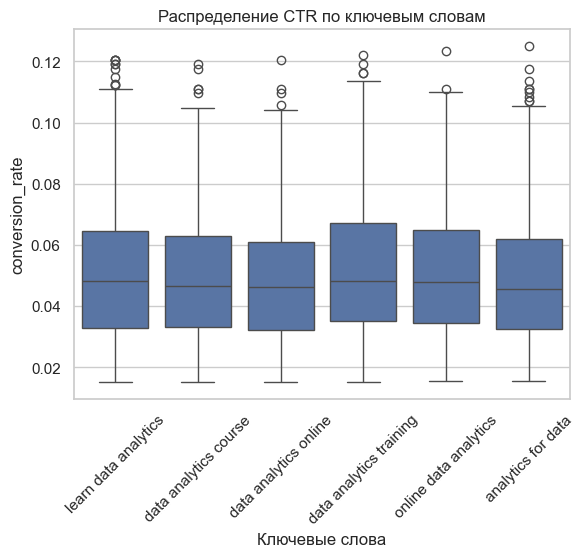

In [51]:
sns.boxplot(x = 'keyword', y = 'conversion_rate', data=df)
plt.title('Распределение CTR по ключевым словам')
plt.xlabel('Ключевые слова')
plt.xticks(rotation=45) 

### 5.3 CTR по ключевым словам

Проведён анализ метрики `CTR` для разных ключевых слов.

### 1. Визуальный анализ

*   **Гистограмма:** Основная часть значений находится в диапазоне 2.5% – 4%. Есть отдельные значения выше 6%.  
*   **Боксплот:** Медианные значения CTR по ключевым словам близки. Разброс в некоторых группах отличается.

### 2. Статистическая проверка

**Тест Левена:**  
$p\text{-value} = 0.0237$ ($< 0.05$)  
Дисперсии различаются.

**Тест Краскела–Уоллиса:**  
$p\text{-value} = 0.6731$ ($> 0.05$)  
Статистически значимых различий в CTR между ключевыми словами нет.

### Итог

CTR по ключевым словам не отличается. Все группы показывают сопоставимые значения.


Text(0.5, 0, 'CTR')

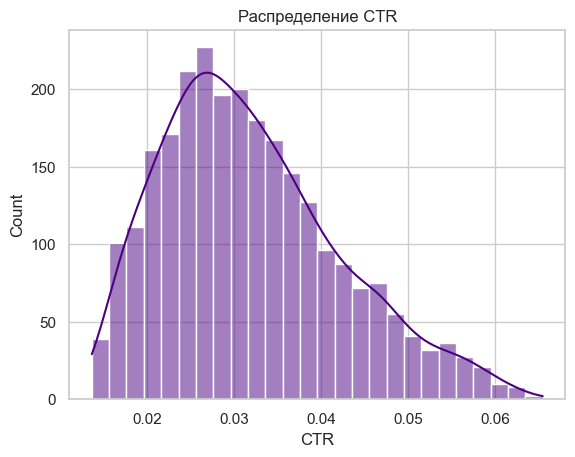

In [52]:
sns.histplot(df['CTR'], kde=True, color='indigo')
plt.title('Распределение CTR')
plt.xlabel('CTR')

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'learn data analytics'),
  Text(1, 0, 'data analytics course'),
  Text(2, 0, 'data analytics online'),
  Text(3, 0, 'data analytics training'),
  Text(4, 0, 'online data analytics'),
  Text(5, 0, 'analytics for data')])

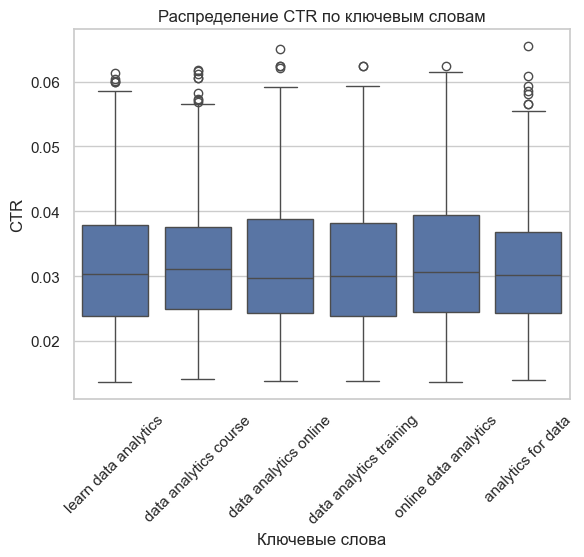

In [53]:
sns.boxplot(x = 'keyword', y = 'CTR', data=df)
plt.title('Распределение CTR по ключевым словам')
plt.xlabel('Ключевые слова')
plt.xticks(rotation=45) 

In [54]:
statistic, p_value = stats.levene(df.query("keyword == 'learn data analytics'")['CTR'],
                                    df.query("keyword == 'data analytics course'")['CTR'],
                                    df.query("keyword == 'data analytics online'")['CTR'],
                                    df.query("keyword == 'data analytics training'")['CTR'],
                                    df.query("keyword == 'online data analytics'")['CTR'],
                                    df.query("keyword == 'analytics for data'")['CTR'])
if p_value <= 0.05:
        print(f"диспресии как минимум одной из групп значимо отличается (p-value = {p_value:.4f})")
else:
    print(f"дисперсии всех групп равны (p-value = {p_value:.4f})")

диспресии как минимум одной из групп значимо отличается (p-value = 0.0237)


In [55]:
stat, p_val = stats.kruskal(df.query("keyword == 'learn data analytics'")['CTR'],
                                    df.query("keyword == 'data analytics course'")['CTR'],
                                    df.query("keyword == 'data analytics online'")['CTR'],
                                    df.query("keyword == 'data analytics training'")['CTR'],
                                    df.query("keyword == 'online data analytics'")['CTR'],
                                    df.query("keyword == 'analytics for data'")['CTR'])
print(f"P-value: {p_val:.4f}")

P-value: 0.6731


### 5.4 ROAS по устройствам и ключевым словам

Для оценки финансовой эффективности кампании были проанализированы показатели ROAS в разрезе двух сегментов: устройств и поисковых запросов.

### Визуальный анализ
* **По устройствам:** Барчарт подтвердил высокую однородность окупаемости.
* **По ключевым словам:** Все запросы имеют стабильную отдачу.

### Статистическая проверка
Для проверки гипотезы о различии в окупаемости ключевых слов был проведен дисперсионный анализ:

1. **Тест Левена:** 
   * **Результат:** $p\text{-value} = 0.3672$ ($> 0.05$).
   * **Вывод:** Дисперсии всех групп равны. 
2. **Однофакторный ANOVA:** 
   * **Результат:** $p\text{-value} = 0.1120$ ($> 0.05$).
   * **Вывод:** Статистически значимых различий между средними значениями ROAS для разных ключевых слов не обнаружено.

### Вывод
Итоговая окупаемость (**ROAS**) по всем сегментам распределена равномерно. 


C:\Users\Игорь\AppData\Local\Temp\ipykernel_10920\2196811928.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='device', y='ROAS', palette='Blues_d', data = roas_device)


Text(0, 0.5, 'ROAS')

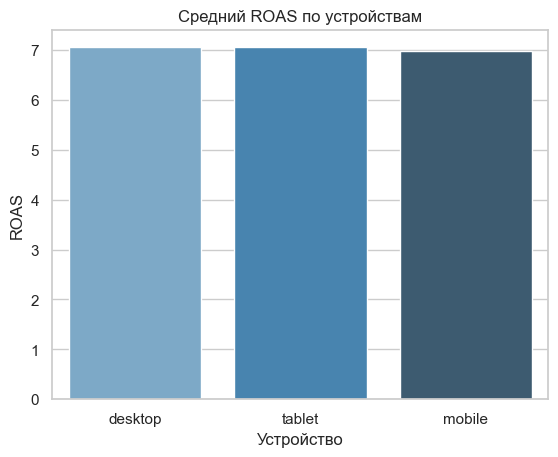

In [56]:
roas_device = df.groupby('device', as_index = False).agg({'ROAS': 'mean'}).sort_values('ROAS', ascending=False)
sns.barplot(x='device', y='ROAS', palette='Blues_d', data = roas_device)

plt.title('Средний ROAS по устройствам')
plt.xlabel('Устройство')
plt.ylabel('ROAS')

C:\Users\Игорь\AppData\Local\Temp\ipykernel_10920\3934376281.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='keyword', y='ROAS', palette='Greens_d', data = roas_keyword)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'data analytics course'),
  Text(1, 0, 'data analytics training'),
  Text(2, 0, 'learn data analytics'),
  Text(3, 0, 'data analytics online'),
  Text(4, 0, 'analytics for data'),
  Text(5, 0, 'online data analytics')])

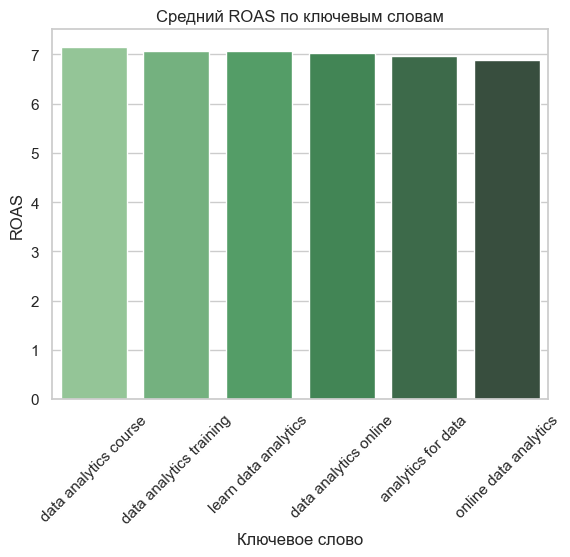

In [57]:
roas_keyword = df.groupby('keyword', as_index = False).agg({'ROAS': 'mean'}).sort_values('ROAS', ascending=False)
sns.barplot(x='keyword', y='ROAS', palette='Greens_d', data = roas_keyword)
plt.title('Средний ROAS по ключевым словам')
plt.xlabel('Ключевое слово')
plt.ylabel('ROAS')
plt.xticks(rotation = 45)


In [58]:
for i in ['learn data analytics', 'data analytics course', 'data analytics online', 'data analytics training', 'online data analytics', 'analytics for data']:
    statistic, p_value = stats.normaltest(df.query("keyword == @i")['ROAS'])
    if p_value <= 0.05:
        print(f"признак {i}: распределение не нормальное (p-value = {p_value:.4f})")
    else:
        print(f"признак {i}: распределение нормальное (p-value = {p_value:.4f})")

признак learn data analytics: распределение не нормальное (p-value = 0.0063)
признак data analytics course: распределение не нормальное (p-value = 0.0000)
признак data analytics online: распределение не нормальное (p-value = 0.0095)
признак data analytics training: распределение не нормальное (p-value = 0.0000)
признак online data analytics: распределение не нормальное (p-value = 0.0000)
признак analytics for data: распределение не нормальное (p-value = 0.0001)


In [59]:
statistic, p_value = stats.levene(df.query("keyword == 'learn data analytics'")['ROAS'], 
                                  df.query("keyword == 'data analytics course'")['ROAS'], 
                                  df.query("keyword == 'data analytics online'")['ROAS'],
                                  df.query("keyword == 'data analytics training'")['ROAS'],
                                  df.query("keyword == 'online data analytics'")['ROAS'],
                                  df.query("keyword == 'analytics for data'")['ROAS'])
if p_value <= 0.05:
        print(f"диспресии как минимум одной из групп значимо отличается (p-value = {p_value:.4f})")
else:
    print(f"дисперсии всех групп равны (p-value = {p_value:.4f})")

дисперсии всех групп равны (p-value = 0.3672)


In [60]:
statistic, p_value = stats.f_oneway(df.query("keyword == 'learn data analytics'")['ROAS'], 
                                    df.query("keyword == 'data analytics course'")['ROAS'], 
                                    df.query("keyword == 'data analytics online'")['ROAS'],
                                    df.query("keyword == 'data analytics training'")['ROAS'],
                                    df.query("keyword == 'online data analytics'")['ROAS'],
                                    df.query("keyword == 'analytics for data'")['ROAS'])
if p_value <= 0.05:
        print(f"среднее хотя одной из групп значимо отличается от средних в других группах (p-value = {p_value:.4f})")
else:
    print(f"средние всех групп равны (p-value = {p_value:.4f})")

средние всех групп равны (p-value = 0.1120)


## Анализ воронки продаж
Основная потеря аудитории происходит на этапе перехода Клики → Лиды (конверсия 14.4%). В то время как отдел продаж или форма оплаты работают крайне эффективно (конверсия из лида в покупку — 32.7%), сам сайт (первое впечатление) теряет более 85% заинтересованного трафика.


In [61]:
funnel_data = df[['impressions', 'clicks', 'leads', 'conversions']].sum().reset_index()
funnel_data.columns = ['Stage', 'Value']

funnel_data['Conversion_%'] = (funnel_data['Value'] / funnel_data['Value'].shift(1) * 100).fillna(100)

display(funnel_data)

fig = px.funnel(funnel_data, x='Value', y='Stage', title='Воронка продаж рекламной кампании')
fig.show()


,Stage,Value,Conversion_%
0,impressions,11760272.0,100.000000
1,clicks,361293.0,3.072148
2,leads,52010.0,14.395518
3,conversions,16985.0,32.657181


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Анализ недельной цикличности

В ходе исследования были проанализированы ключевые метрики (**Clicks, Cost, Conversion Rate, Sale Amount, ROAS**) в разрезе дней недели. На графиках оранжевым цветом выделены лидеры по каждому показателю.

### Основные наблюдения:
1. **Пик эффективности (Суббота):** Суббота является наиболее выгодным днем для бизнеса. При минимальных средних затратах достигается максимальный показатель ROAS (7.18).
2. **Максимальный охват (Понедельник):** В начале недели фиксируется всплеск интереса (в среднем 142 клика).

### Статистическая проверка (Тесты Левена и Краскела-Уоллиса):
Несмотря на визуальные различия, статистический анализ показал, что кампания работает крайне устойчиво. Ни по одной из метрик не выявлено **статистически значимых различий** между днями недели ($p > 0.05$).

**Рекомендация:**
Текущая рекламная стратегия обеспечивает высокую стабильность результатов вне зависимости от дня недели. Однако, учитывая тенденции в показателях ROAS и Cost, рекомендуется протестировать небольшое перераспределение бюджета (~10%) с воскресенья на субботу и понедельник для потенциального увеличения общей маржинальности.



In [ ]:
df['day_of_week'] = df['ad_date'].dt.day_name()
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_analysis = df.groupby('day_of_week').agg({
    'clicks': 'mean',
    'cost': 'mean',
    'conversion_rate': 'mean',
    'sale_amount': 'mean',
    'ROAS': 'mean'
}).reindex(days_order)

print("Средние метрики по дням недели:")
display(weekly_analysis)

Средние метрики по дням недели:


,clicks,cost,conversion_rate,sale_amount,ROAS
day_of_week,,,,,
Monday,142.084034,213.882409,0.047604,1512.394958,7.139886
Tuesday,138.257143,215.872600,0.050543,1480.905714,6.920391
Wednesday,137.828488,216.294884,0.051154,1490.735465,6.946221
Thursday,138.255376,214.580645,0.050433,1504.879032,7.067626
Friday,138.427918,216.453364,0.050214,1506.535469,7.022738
Saturday,137.708531,212.787796,0.051031,1513.545024,7.175754
Sunday,140.657233,216.209686,0.049878,1476.182390,6.875205


C:\Users\Игорь\AppData\Local\Temp\ipykernel_408\2307568347.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(weekly_analysis.index, rotation=45)
C:\Users\Игорь\AppData\Local\Temp\ipykernel_408\2307568347.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(weekly_analysis.index, rotation=45)
C:\Users\Игорь\AppData\Local\Temp\ipykernel_408\2307568347.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(weekly_analysis.index, rotation=45)
C:\Users\Игорь\AppData\Local\Temp\ipykernel_408\2307568347.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(weekly_analy

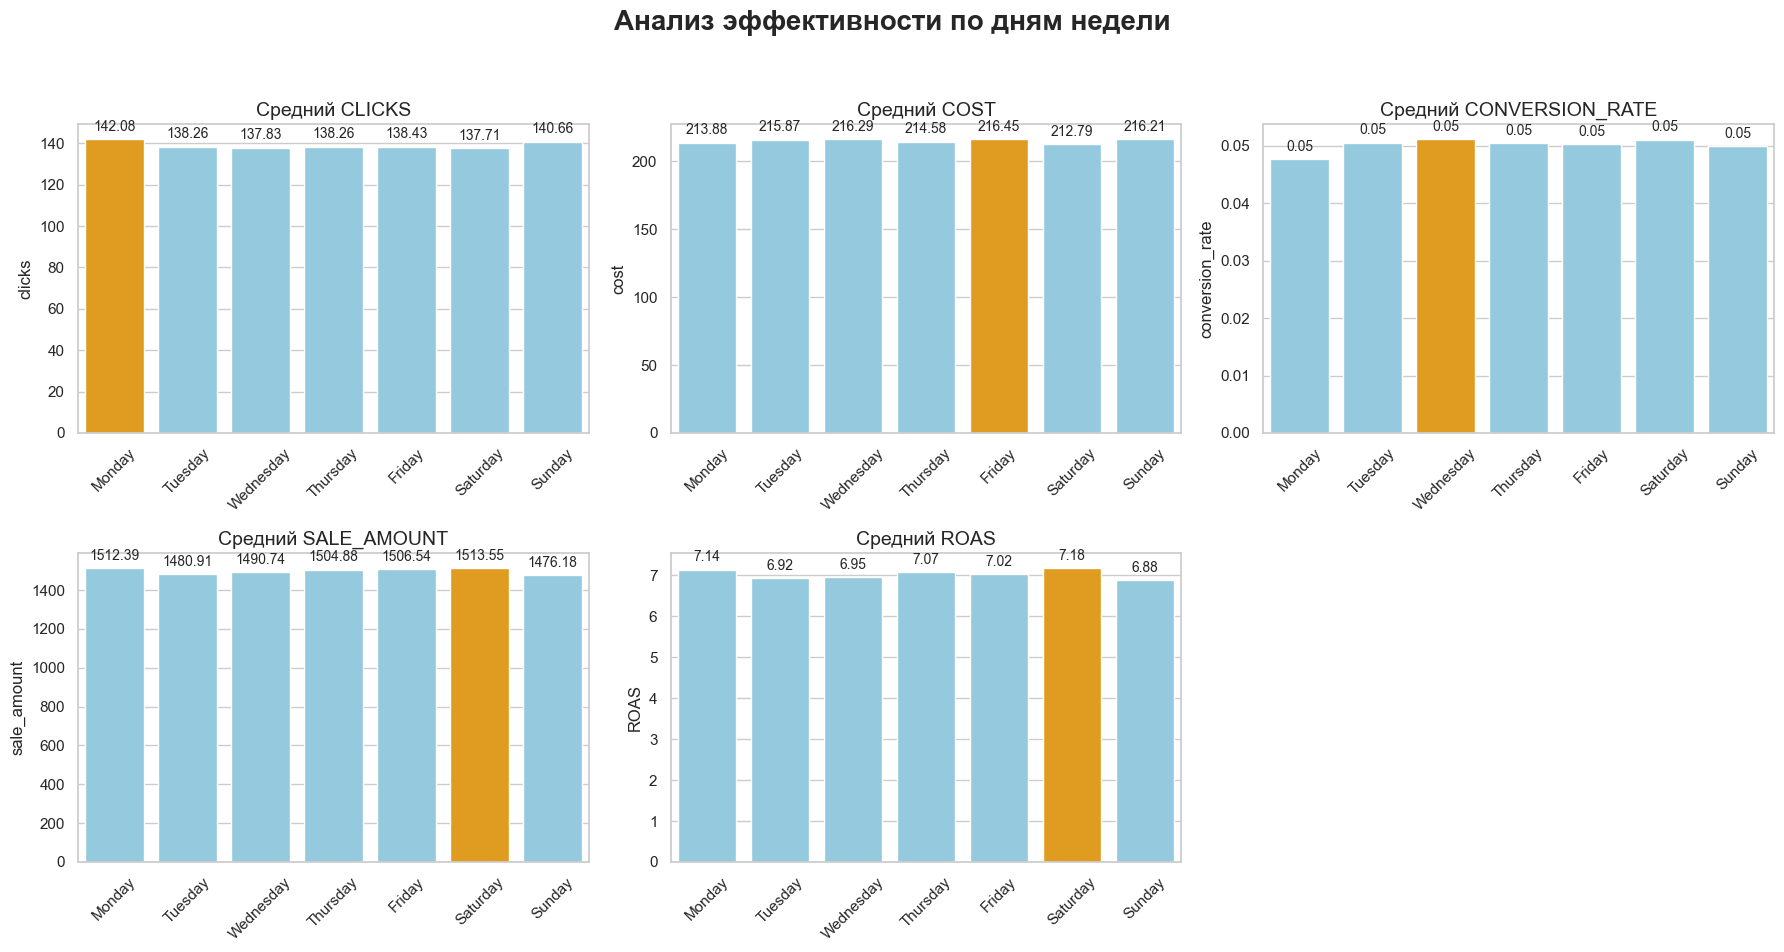

In [ ]:
metrics = ['clicks', 'cost', 'conversion_rate', 'sale_amount', 'ROAS']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ эффективности по дням недели', fontsize=20, fontweight='bold')
axes = axes.flatten()

for i, metric in enumerate(metrics):
    colors = ['skyblue' if (x < weekly_analysis[metric].max()) else 'orange' for x in weekly_analysis[metric]]
    
    sns.barplot(x=weekly_analysis.index, y=metric, data=weekly_analysis, 
                ax=axes[i], palette=colors, hue=weekly_analysis.index)
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}', 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 9), 
                         textcoords='offset points', fontsize=10)
    
    axes[i].set_title(f'Средний {metric.upper()}', fontsize=14)
    axes[i].set_xticklabels(weekly_analysis.index, rotation=45)
    axes[i].set_xlabel('')

fig.delaxes(axes[5])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
metrics = ['clicks', 'cost', 'conversion_rate', 'sale_amount', 'ROAS']

for metric in metrics:
    samples = [df.query("day_of_week == @day")[metric] for day in days_order]
    
    print(f"--- Анализ метрики: {metric.upper()} ---")
    
    stat_l, p_l = stats.levene(*samples)
    print(f"Тест Левена: p-value = {p_l:.4f}")
    
    stat_k, p_k = stats.kruskal(*samples)
    print(f"Тест Краскела-Уоллиса: p-value = {p_k:.4f}")
    
    if p_k < 0.05:
        print(f"РЕЗУЛЬТАТ: Обнаружены значимые различия по дням недели")
    else:
        print(f"РЕЗУЛЬТАТ: Различия статистически не значимы.")
    print("-" * 30)


--- Анализ метрики: CLICKS ---
Тест Левена: p-value = 0.8778
Тест Краскела-Уоллиса: p-value = 0.5168
РЕЗУЛЬТАТ: Различия статистически не значимы.
------------------------------
--- Анализ метрики: COST ---
Тест Левена: p-value = 0.9885
Тест Краскела-Уоллиса: p-value = 0.0628
РЕЗУЛЬТАТ: Различия статистически не значимы.
------------------------------
--- Анализ метрики: CONVERSION_RATE ---
Тест Левена: p-value = 0.6455
Тест Краскела-Уоллиса: p-value = 0.3412
РЕЗУЛЬТАТ: Различия статистически не значимы.
------------------------------
--- Анализ метрики: SALE_AMOUNT ---
Тест Левена: p-value = 0.0727
Тест Краскела-Уоллиса: p-value = 0.4317
РЕЗУЛЬТАТ: Различия статистически не значимы.
------------------------------
--- Анализ метрики: ROAS ---
Тест Левена: p-value = 0.1519
Тест Краскела-Уоллиса: p-value = 0.0927
РЕЗУЛЬТАТ: Различия статистически не значимы.
------------------------------


## Итоговые выводы по проекту

### Что было сделано
В ходе проекта проведён полный цикл анализа рекламных данных Google Ads:
1. **Предобработка:** очищены опечатки, типизированы столбцы, восстановлены пропуски без потери строк.
2. **EDA:** изучены распределения ключевых метрик, временные ряды, корреляции.
3. **Статистическое тестирование:** проверены гипотезы о различиях conversion_rate и CTR по устройствам и ключевым словам, а также основных метрик по дням недели(тест Левена, ANOVA, Краскел–Уоллис).
4. **Воронка:** количественно оценён отток на каждом этапе.

---

### Ключевые находки

**1. Устройства не влияют на конверсию**   
Кампания одинаково хорошо работает на компьютерах, смартфонах и планшетах. Это говорит о том, что сайт одинаково удобен и корректно отображается на любых экранах. Перераспределение бюджета между устройствами без дополнительного тестирования не обосновано.

**2. Ключевые слова не влияют на CTR**   
Все ключевые слова привлекают трафик с одинаковой интенсивностью. Объявления воспринимаются аудиторией примерно одинаково вне зависимости от формулировки запроса.

**3. Воронка: главное узкое место — переход «Клики → Лиды»**  
Наибольший относительный отток происходит здесь. Это указывает на недостаточную убедительность главной страницы сайта.

**4. Волатильность трафика во второй половине ноября**  
После 15 ноября показатели стали выше, но менее стабильными.

---


## Предлагаемые A/B-тесты


---

### Тест 1. Одна кнопка вместо длинной страницы


**Гипотеза:** Если оставить на странице всего одно целевое действие и короткую форму (имя + почта), заявок станет больше.

| Вариант | Описание |
|:--|:--|
| A (контроль) | Текущая страница |
| B (тест) | Один экран, одна кнопка, форма из двух полей |

**Метрика:** Leads / Clicks.

**Обоснование:** Сейчас на этом этапе теряются 85% людей. При этом те, кто все же оставил заявку, покупают очень хорошо (32%). Значит, нужно просто упростить вход.


---

### Тест 2. Текст объявления: глагол-намерение против информационного заголовка


**Гипотеза:** Заголовки с призывом к действию («Стань», «Освой») соберут больше кликов, чем просто информационный текст.

| Вариант | Заголовок |
|:--|:--|
| A (контроль) | Текущая реклама |
| B (тест) | Призывы вроде «Стань аналитиком данных» или «Освой профессию с нуля» |

**Метрика:** CTR.

**Обоснование:** Реклама на разные ключевые слова работает одинаково вяло. Значит, дело не в том, кому было показывано объявление, а в том, что именно в нем написано.
